# XLM-RoBERTa-Large Bi-Encoder v3
## RFQ–Supplier Match Classification

**Key fixes over v2:**
- **Full deterministic training** — seeded RNG, cuDNN deterministic, CUBLAS config
- **Class-weighted Focal Loss** — compensates for `weak_match` under-representation
- **Mean pooling** instead of CLS (better sentence representations)
- **Element-wise product** for richer RFQ–Supplier interaction
- **2-phase training** (head warmup → LLRD) instead of fragile 3-phase unfreezing
- **Layer-wise Learning Rate Decay** for stable fine-tuning
- **bf16** mixed precision (more stable than fp16 on A100)
- **Robust CSV loading** — recovers rows dropped by v2
- **A100-optimised batch sizes**

In [1]:
!pip install -q transformers datasets accelerate scikit-learn

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import os, warnings, shutil, random
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from transformers import (AutoTokenizer, AutoModel,
                          TrainingArguments, Trainer,
                          EarlyStoppingCallback)
from torch.utils.data import Dataset as TorchDataset
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

seed_everything()

if not torch.cuda.is_available():
    raise RuntimeError("GPU not found! Runtime > Change runtime type > GPU")

device = torch.device("cuda")
print(f"GPU:  {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

GPU:  NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [4]:
LABEL2ID = {"match": 0, "weak_match": 1, "related": 2, "no_match": 3}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = len(LABEL2ID)

MODEL_NAME = "xlm-roberta-large"
RFQ_MAX_LEN  = 256
SUP_MAX_LEN  = 512
NUM_STRUCTURED = 7

EUROPEAN = {
    "DE","FR","ES","IT","NL","BE","AT","PT","PL","CZ","SK","HU","RO",
    "BG","HR","SI","LT","LV","EE","FI","SE","DK","IE","GR","LU","MT",
    "CY","CH","NO","GB","UK",
}

TYPE_NORM = {
    "manufacturer": "production",
    "production": "production",
    "customerspecificmanufacturing": "production",
    "wholesaler": "wholesaler",
    "trader": "wholesaler",
    "service": "service",
    "serviceprovider": "service",
}


def clean_array_field(s):
    if pd.isna(s):
        return ""
    s = str(s).strip()
    if s.startswith("{") and s.endswith("}"):
        s = s[1:-1]
    return s.replace(",", ", ")


def build_rfq_text(row):
    parts = [
        row["rfq_title"],
        str(row["rfq_description"])[:700],
        f"Types: {row['rfq_supplier_types']}",
        f"Delivery: {row['delivery_location']}",
        f"Qty: {row['quantity']}",
    ]
    return " | ".join(p for p in parts if str(p).strip())


def build_supplier_text(row):
    parts = [
        row["supplier_types"],
        str(row["products"])[:500],
        row["product_categories"],
        row["keywords"],
        row["supplier_name"],
        f"{row['supplier_country']} {row['distribution_area']}".strip(),
        str(row["supplier_description"])[:800],
    ]
    return " | ".join(p for p in parts if str(p).strip())


def _norm_types(s):
    toks = {t.strip().lower() for t in str(s).split(",") if t.strip()}
    return {TYPE_NORM.get(t, t) for t in toks}


def type_jaccard(a, b):
    sa, sb = _norm_types(a), _norm_types(b)
    if not sa or not sb:
        return 0.0
    return len(sa & sb) / len(sa | sb)


def region_compat(delivery, sup_country, dist_area):
    da = str(dist_area).lower().strip()
    if da in ("", "nan"):
        return 0.5
    if da == "international":
        return 1.0
    if da == "europe":
        return 1.0 if delivery.upper() in EUROPEAN else 0.0
    if da in ("national", "local"):
        return 1.0 if delivery.upper() == sup_country.upper() else 0.0
    return 0.5


def extract_features(row):
    return [
        float(str(row["delivery_location"]).upper()
              == str(row["supplier_country"]).upper()),
        region_compat(row["delivery_location"],
                      row["supplier_country"],
                      row["distribution_area"]),
        type_jaccard(row["rfq_supplier_types"], row["supplier_types"]),
        min(len(str(row["rfq_description"])) / 1000.0, 3.0),
        min(len(str(row["supplier_description"])) / 1000.0, 5.0),
        float(len(str(row["keywords"]).strip()) > 0),
        float(len(str(row["products"]).strip()) > 0),
    ]

In [5]:
try:
    df = pd.read_csv("/content/result_dataset_balanced_56k.csv")
except pd.errors.ParserError:
    df = pd.read_csv("/content/result_dataset_balanced_56k.csv",
                     on_bad_lines="skip", engine="python")
    print(f"WARNING: rows dropped due to CSV parsing errors")

print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")

ARRAY_COLS = ["rfq_supplier_types", "supplier_types", "products",
              "product_categories", "keywords"]
TEXT_COLS  = [
    "rfq_title", "rfq_description", "delivery_location", "quantity",
    "rfq_supplier_types", "supplier_name", "supplier_country",
    "distribution_area", "supplier_description", "supplier_types",
    "products", "product_categories", "keywords",
]

for col in ARRAY_COLS:
    df[col] = df[col].apply(clean_array_field)
for col in TEXT_COLS:
    df[col] = df[col].fillna("").astype(str)

df["text_rfq"]      = df.apply(build_rfq_text, axis=1)
df["text_supplier"] = df.apply(build_supplier_text, axis=1)
df["label"]         = df["match_type"].map(LABEL2ID)
df["features"]      = df.apply(extract_features, axis=1)

print(f"RFQ text:      mean={df['text_rfq'].str.len().mean():.0f}  "
      f"max={df['text_rfq'].str.len().max()} chars")
print(f"Supplier text: mean={df['text_supplier'].str.len().mean():.0f}  "
      f"max={df['text_supplier'].str.len().max()} chars")

print(f"\nGlobal label distribution:")
print(df["label"].value_counts().sort_index().rename(ID2LABEL))

Loaded 56,000 rows, 16 columns
RFQ text:      mean=552  max=998 chars
Supplier text: mean=4456  max=49014 chars

Global label distribution:
label
match         14000
weak_match    14000
related       14000
no_match      14000
Name: count, dtype: int64


In [6]:
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
tv_idx, te_idx = next(gss1.split(df, df["label"], groups=df["rfq_id"]))
df_tv   = df.iloc[tv_idx].reset_index(drop=True)
df_test = df.iloc[te_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=SEED)
tr_idx, va_idx = next(gss2.split(df_tv, df_tv["label"],
                                  groups=df_tv["rfq_id"]))
df_train = df_tv.iloc[tr_idx].reset_index(drop=True)
df_val   = df_tv.iloc[va_idx].reset_index(drop=True)

print(f"Train: {len(df_train):,}   Val: {len(df_val):,}   Test: {len(df_test):,}")

train_counts = df_train["label"].value_counts().sort_index()
print(f"\nTrain label distribution:")
for idx, cnt in train_counts.items():
    print(f"  {ID2LABEL[idx]:>12s}: {cnt:,}")

class_weights = (len(df_train) / (NUM_LABELS * train_counts.values.astype(float)))
class_weights = (class_weights / class_weights.mean()).tolist()
print(f"\nComputed class weights: {[f'{w:.3f}' for w in class_weights]}")

Train: 38,753   Val: 5,982   Test: 11,265

Train label distribution:
         match: 9,643
    weak_match: 9,659
       related: 9,947
      no_match: 9,504

Computed class weights: ['1.004', '1.003', '0.974', '1.019']


In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def batch_tokenize(texts, max_len):
    return tokenizer(
        texts, truncation=True, max_length=max_len,
        padding=False, return_attention_mask=True,
    )


print("Tokenizing RFQ texts ...")
train_rfq = batch_tokenize(df_train["text_rfq"].tolist(), RFQ_MAX_LEN)
val_rfq   = batch_tokenize(df_val["text_rfq"].tolist(),   RFQ_MAX_LEN)
test_rfq  = batch_tokenize(df_test["text_rfq"].tolist(),  RFQ_MAX_LEN)

print("Tokenizing Supplier texts ...")
train_sup = batch_tokenize(df_train["text_supplier"].tolist(), SUP_MAX_LEN)
val_sup   = batch_tokenize(df_val["text_supplier"].tolist(),   SUP_MAX_LEN)
test_sup  = batch_tokenize(df_test["text_supplier"].tolist(),  SUP_MAX_LEN)

rfq_lens = [len(x) for x in train_rfq["input_ids"]]
sup_lens = [len(x) for x in train_sup["input_ids"]]
print(f"RFQ tokens:      mean={np.mean(rfq_lens):.0f}  "
      f"max={max(rfq_lens)}  at_limit={sum(l >= RFQ_MAX_LEN for l in rfq_lens)}")
print(f"Supplier tokens: mean={np.mean(sup_lens):.0f}  "
      f"max={max(sup_lens)}  at_limit={sum(l >= SUP_MAX_LEN for l in sup_lens)}")


class BiEncoderDataset(TorchDataset):
    def __init__(self, rfq_enc, sup_enc, labels, features):
        self.rfq_ids  = rfq_enc["input_ids"]
        self.rfq_mask = rfq_enc["attention_mask"]
        self.sup_ids  = sup_enc["input_ids"]
        self.sup_mask = sup_enc["attention_mask"]
        self.labels   = labels
        self.features = features

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "rfq_input_ids":       self.rfq_ids[idx],
            "rfq_attention_mask":  self.rfq_mask[idx],
            "sup_input_ids":       self.sup_ids[idx],
            "sup_attention_mask":  self.sup_mask[idx],
            "structured_features": self.features[idx],
            "labels":              self.labels[idx],
        }


class BiEncoderCollator:
    def __init__(self, pad_id):
        self.pad_id = pad_id

    def _pad(self, seqs, pad_val):
        t = [torch.tensor(s, dtype=torch.long) for s in seqs]
        return nn.utils.rnn.pad_sequence(t, batch_first=True,
                                         padding_value=pad_val)

    def __call__(self, batch):
        return {
            "rfq_input_ids":
                self._pad([b["rfq_input_ids"] for b in batch], self.pad_id),
            "rfq_attention_mask":
                self._pad([b["rfq_attention_mask"] for b in batch], 0),
            "sup_input_ids":
                self._pad([b["sup_input_ids"] for b in batch], self.pad_id),
            "sup_attention_mask":
                self._pad([b["sup_attention_mask"] for b in batch], 0),
            "structured_features": torch.tensor(
                [b["structured_features"] for b in batch], dtype=torch.float),
            "labels": torch.tensor(
                [b["labels"] for b in batch], dtype=torch.long),
        }


ds_train = BiEncoderDataset(train_rfq, train_sup,
                            df_train["label"].tolist(),
                            df_train["features"].tolist())
ds_val   = BiEncoderDataset(val_rfq, val_sup,
                            df_val["label"].tolist(),
                            df_val["features"].tolist())
ds_test  = BiEncoderDataset(test_rfq, test_sup,
                            df_test["label"].tolist(),
                            df_test["features"].tolist())

print(f"\nDatasets: train={len(ds_train)}, val={len(ds_val)}, test={len(ds_test)}")

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing RFQ texts ...
Tokenizing Supplier texts ...
RFQ tokens:      mean=148  max=256  at_limit=759
Supplier tokens: mean=401  max=512  at_limit=21136

Datasets: train=38753, val=5982, test=11265


In [8]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, label_smoothing=0.1,
                 num_classes=4, class_weights=None):
        super().__init__()
        self.gamma = gamma
        self.ls    = label_smoothing
        self.nc    = num_classes
        self.cw    = class_weights

    def forward(self, logits, labels):
        one_hot = F.one_hot(labels, self.nc).float()
        targets = one_hot * (1.0 - self.ls) + self.ls / self.nc
        log_p   = F.log_softmax(logits, dim=-1)
        p       = log_p.exp()
        focal   = ((1 - p) ** self.gamma) * targets * (-log_p)
        if self.cw is not None:
            w = torch.tensor(self.cw, device=logits.device,
                             dtype=logits.dtype).unsqueeze(0)
            focal = focal * w
        return focal.sum(dim=-1).mean()


class BiEncoderClassifier(nn.Module):
    """Bi-encoder with mean pooling, element-wise diff & product,
    structured features, and MLP classifier head."""

    def __init__(self, model_name, num_labels, num_features, dropout=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.config = self.encoder.config
        self.config.num_labels = num_labels

        self.pre_drop = nn.Dropout(0.1)

        self.head = nn.Sequential(
            nn.Linear(h * 4 + num_features, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, num_labels),
        )
        self._init_head()

    def _init_head(self):
        torch.manual_seed(SEED)
        for m in self.head:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def _pool(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids,
                           attention_mask=attention_mask)
        hidden = out.last_hidden_state
        mask   = attention_mask.unsqueeze(-1).float()
        return (hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

    def forward(self, rfq_input_ids, rfq_attention_mask,
                sup_input_ids, sup_attention_mask,
                structured_features, labels=None, **kw):
        r = self.pre_drop(self._pool(rfq_input_ids, rfq_attention_mask))
        s = self.pre_drop(self._pool(sup_input_ids, sup_attention_mask))
        x = torch.cat([r, s, torch.abs(r - s), r * s,
                       structured_features], dim=-1)
        logits = self.head(x)
        return {"logits": logits}


seed_everything()
model = BiEncoderClassifier(MODEL_NAME, NUM_LABELS, NUM_STRUCTURED)
total_p = sum(p.numel() for p in model.parameters())
print(f"Total parameters:    {total_p:,}")
print(f"Encoder hidden size: {model.encoder.config.hidden_size}")

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters:    562,059,140
Encoder hidden size: 1024


In [9]:
def get_llrd_groups(model, head_lr=3e-5, lr_decay=0.95, wd=0.01):
    no_decay = {"bias", "LayerNorm.weight", "LayerNorm.bias"}
    groups = []

    layers = list(model.encoder.encoder.layer)
    num_layers = len(layers)

    emb_lr = head_lr * (lr_decay ** (num_layers + 1))
    emb_d, emb_nd = [], []
    for n, p in model.encoder.embeddings.named_parameters():
        if not p.requires_grad:
            continue
        (emb_nd if any(nd in n for nd in no_decay) else emb_d).append(p)
    if emb_d:
        groups.append({"params": emb_d, "lr": emb_lr, "weight_decay": wd})
    if emb_nd:
        groups.append({"params": emb_nd, "lr": emb_lr, "weight_decay": 0.0})

    for i, layer in enumerate(layers):
        layer_lr = head_lr * (lr_decay ** (num_layers - i))
        d_p, nd_p = [], []
        for n, p in layer.named_parameters():
            if not p.requires_grad:
                continue
            (nd_p if any(nd in n for nd in no_decay) else d_p).append(p)
        if d_p:
            groups.append({"params": d_p, "lr": layer_lr, "weight_decay": wd})
        if nd_p:
            groups.append({"params": nd_p, "lr": layer_lr, "weight_decay": 0.0})

    head_d, head_nd = [], []
    for n, p in model.head.named_parameters():
        if not p.requires_grad:
            continue
        (head_nd if any(nd in n for nd in no_decay) else head_d).append(p)
    if head_d:
        groups.append({"params": head_d, "lr": head_lr, "weight_decay": wd})
    if head_nd:
        groups.append({"params": head_nd, "lr": head_lr, "weight_decay": 0.0})

    return groups


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":    accuracy_score(labels, preds),
        "f1_macro":    f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }


class BiEncoderTrainer(Trainer):
    def __init__(self, *args, focal_loss_fn=None, llrd_config=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.focal_loss_fn = focal_loss_fn or FocalLoss()
        self.llrd_config = llrd_config

    def create_optimizer(self):
        if self.llrd_config is not None:
            groups = get_llrd_groups(
                self.model,
                head_lr=self.llrd_config["head_lr"],
                lr_decay=self.llrd_config["lr_decay"],
                wd=self.llrd_config.get("weight_decay", 0.01),
            )
            self.optimizer = torch.optim.AdamW(groups)
            return self.optimizer
        return super().create_optimizer()

    def _fwd(self, model, inputs):
        return model(
            rfq_input_ids=inputs["rfq_input_ids"],
            rfq_attention_mask=inputs["rfq_attention_mask"],
            sup_input_ids=inputs["sup_input_ids"],
            sup_attention_mask=inputs["sup_attention_mask"],
            structured_features=inputs["structured_features"],
        )

    def compute_loss(self, model, inputs, return_outputs=False, **kw):
        labels  = inputs["labels"]
        outputs = self._fwd(model, inputs)
        loss    = self.focal_loss_fn(outputs["logits"], labels)
        return (loss, outputs) if return_outputs else loss

    def prediction_step(self, model, inputs, prediction_loss_only,
                        ignore_keys=None, **kwargs):
        inputs = self._prepare_inputs(inputs)
        with torch.no_grad():
            outputs = self._fwd(model, inputs)
            logits  = outputs["logits"]
            loss    = self.focal_loss_fn(logits, inputs["labels"])
        if prediction_loss_only:
            return (loss, None, None)
        return (loss, logits, inputs["labels"])

## Training Plan

| Phase | What trains | LR | Epochs | Batch |
|-------|-------------|-----|--------|-------|
| 1 — Head warmup | Classifier head only (encoder frozen) | 5e-4 | 3 | 64 |
| 2 — Full LLRD | All parameters (layer-wise LR decay 0.95) | 3e-5 → 8e-6 | 10 | 16×2 |

Phase 2 uses **Layer-wise Learning Rate Decay**: top encoder layers get `3e-5`,
bottom layers get `~8e-6`, embeddings get `~6e-6`. This replaces the fragile
3-phase unfreezing from v2 with a single stable training run.

In [11]:
def freeze_encoder(m):
    for p in m.encoder.parameters():
        p.requires_grad = False

def unfreeze_all(m):
    for p in m.parameters():
        p.requires_grad = True

def count_trainable(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


collator = BiEncoderCollator(tokenizer.pad_token_id)
focal_loss = FocalLoss(gamma=2.0, label_smoothing=0.1,
                       num_classes=NUM_LABELS,
                       class_weights=class_weights)
OUTPUT_DIR = "/content/xlmr-biencoder-v3"

print("=" * 60)
print("PHASE 1: Head warmup (encoder frozen)")
print("=" * 60)

seed_everything()
freeze_encoder(model)
model.encoder.gradient_checkpointing_disable()
print(f"Trainable parameters: {count_trainable(model):,}")

args_p1 = TrainingArguments(
    output_dir=f"{OUTPUT_DIR}/phase1",
    num_train_epochs=3,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=128,
    gradient_accumulation_steps=1,
    learning_rate=5e-4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    bf16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    dataloader_num_workers=2,
    seed=SEED,
    data_seed=SEED
)

trainer_p1 = BiEncoderTrainer(
    model=model,
    args=args_p1,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    data_collator=collator,
    compute_metrics=compute_metrics,
    focal_loss_fn=focal_loss,
)

trainer_p1.train()
p1_f1 = trainer_p1.state.best_metric
print(f"\nPhase 1 best val f1_macro: {p1_f1:.4f}")

PHASE 1: Head warmup (encoder frozen)
Trainable parameters: 2,168,708


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.779043,0.777810,0.322467,0.197930,0.203316
2,0.770971,0.773188,0.330659,0.249011,0.256185
3,0.766579,0.773460,0.326145,0.294628,0.297603



Phase 1 best val f1_macro: 0.2946


In [13]:
print("=" * 60)
print("PHASE 2: Full fine-tuning with LLRD")
print("=" * 60)

seed_everything()
unfreeze_all(model)
model.encoder.gradient_checkpointing_enable()
print(f"Trainable parameters: {count_trainable(model):,}")

LLRD_CONFIG = {
    "head_lr": 3e-5,
    "lr_decay": 0.95,
    "weight_decay": 0.01,
}

args_p2 = TrainingArguments(
    output_dir=f"{OUTPUT_DIR}/phase2",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    learning_rate=3e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    bf16=True,
    eval_strategy="steps",
    eval_steps=300,
    save_strategy="steps",
    save_steps=300,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    dataloader_num_workers=2,
    seed=SEED,
    data_seed=SEED
)

trainer_p2 = BiEncoderTrainer(
    model=model,
    args=args_p2,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    data_collator=collator,
    compute_metrics=compute_metrics,
    focal_loss_fn=focal_loss,
    llrd_config=LLRD_CONFIG,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
)

trainer_p2.train()
p2_f1 = trainer_p2.state.best_metric
print(f"\nPhase 2 best val f1_macro: {p2_f1:.4f}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


PHASE 2: Full fine-tuning with LLRD
Trainable parameters: 562,059,140


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
300,1.386813,0.723771,0.389168,0.378300,0.382640
600,1.204408,0.753430,0.400702,0.396157,0.397554
900,0.946429,1.063192,0.334504,0.326636,0.322313
1200,0.910776,1.207870,0.333166,0.316763,0.313399
1500,0.858537,1.147099,0.308927,0.268446,0.263388
1800,0.812741,1.297619,0.310766,0.274137,0.269991
2100,0.796037,1.189288,0.332665,0.303828,0.299712



Phase 2 best val f1_macro: 0.3962


## Test Set Evaluation

              precision    recall  f1-score   support

       match     0.2979    0.1829    0.2266      2789
  weak_match     0.3056    0.3479    0.3254      2915
     related     0.3533    0.4307    0.3882      2777
    no_match     0.4898    0.5014    0.4956      2784

    accuracy                         0.3654     11265
   macro avg     0.3617    0.3657    0.3589     11265
weighted avg     0.3610    0.3654    0.3585     11265



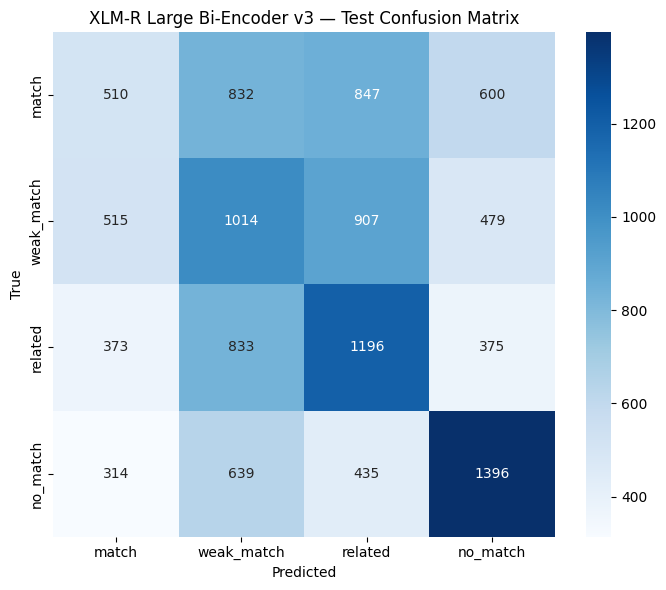


Test macro-F1:  0.3589
Test accuracy:  0.3654

Training summary:
  Phase 1 (head warmup):   val f1_macro = 0.2946
  Phase 2 (LLRD full):     val f1_macro = 0.3962


In [14]:
test_out    = trainer_p2.predict(ds_test)
test_preds  = np.argmax(test_out.predictions, axis=-1)
test_labels = test_out.label_ids

label_names = [ID2LABEL[i] for i in range(NUM_LABELS)]

print(classification_report(test_labels, test_preds,
                            target_names=label_names, digits=4))

cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("XLM-R Large Bi-Encoder v3 \u2014 Test Confusion Matrix")
plt.tight_layout()
plt.show()

test_f1  = f1_score(test_labels, test_preds, average="macro")
test_acc = accuracy_score(test_labels, test_preds)
print(f"\nTest macro-F1:  {test_f1:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")
print(f"\nTraining summary:")
print(f"  Phase 1 (head warmup):   val f1_macro = {p1_f1:.4f}")
print(f"  Phase 2 (LLRD full):     val f1_macro = {p2_f1:.4f}")

In [ ]:
SAVE_DIR = "/content/xlmr-biencoder-v3-final"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "model_config": {
        "model_name": MODEL_NAME,
        "num_labels": NUM_LABELS,
        "num_features": NUM_STRUCTURED,
    },
    "class_weights": class_weights,
    "label2id": LABEL2ID,
    "id2label": ID2LABEL,
}, os.path.join(SAVE_DIR, "bi_encoder.pt"))
tokenizer.save_pretrained(SAVE_DIR)

print(f"Model saved to {SAVE_DIR}")
print(f"Contents: {', '.join(os.listdir(SAVE_DIR))}")

DRIVE_DEST = "/content/drive/MyDrive/xlmr-biencoder-v3-final"
try:
    shutil.copytree(SAVE_DIR, DRIVE_DEST, dirs_exist_ok=True)
    print(f"Copied to {DRIVE_DEST}")
except Exception as e:
    print(f"Drive copy skipped: {e}")

Model saved to /content/xlmr-biencoder-v3-final
Contents: bi_encoder.pt, tokenizer_config.json, tokenizer.json


In [ ]:
test_cases = [
    {
        "rfq_title": "Korktaschen, Korkrucks\u00e4cke, Korkreisetaschen",
        "rfq_description": "Ich bin auf der Suche nach Korktaschen. Anzahl: 10-50, Einmalig.",
        "delivery_location": "DE",
        "quantity": "10 - 50",
        "rfq_supplier_types": "MANUFACTURER, WHOLESALER",
        "supplier_name": "FARL CORK UNIPESSOAL, LDA",
        "supplier_country": "PT",
        "distribution_area": "international",
        "supplier_description": "FARL CORK is a company in the cork industry, from forest to final product.",
        "supplier_types": "Production",
        "products": "Natural yoga block, Cork Specialties, Granules, Corks",
        "product_categories": "Wood and wood products",
        "keywords": "cork, yoga, granules",
    },
    {
        "rfq_title": "High-End Leather Card Holders / Wallets",
        "rfq_description": "Looking for manufacturing partner for card holder models. Premium quality.",
        "delivery_location": "FR",
        "quantity": "20-100",
        "rfq_supplier_types": "PRODUCTION",
        "supplier_name": "GUARNICIONERIA HNOS. PEDRAZA",
        "supplier_country": "ES",
        "distribution_area": "",
        "supplier_description": "WE ARE LEATHER ARTISANS, MANUFACTURING ALL TYPES OF ITEMS.",
        "supplier_types": "Production",
        "products": "",
        "product_categories": "Textile production",
        "keywords": "",
    },
    {
        "rfq_title": "Korktaschen, Korkrucks\u00e4cke, Korkreisetaschen",
        "rfq_description": "Ich bin auf der Suche nach Korktaschen. Anzahl: 10-50, Einmalig.",
        "delivery_location": "DE",
        "quantity": "10 - 50",
        "rfq_supplier_types": "MANUFACTURER, WHOLESALER",
        "supplier_name": "PROMOEASO",
        "supplier_country": "ES",
        "distribution_area": "europe",
        "supplier_description": "Online catalog with 5000 references for corporate and promotional gifts.",
        "supplier_types": "Wholesaler",
        "products": "Shopping Bags, promotional umbrellas, Customized Mugs",
        "product_categories": "Advertising materials",
        "keywords": "Regalos, bolsas, mochilas",
    },
    {
        "rfq_title": "High-quality No-stick Inner Coating Hot Pot Set",
        "rfq_description": "Interested in Hot Pot Set. Material: Stainless Steel.",
        "delivery_location": "DE",
        "quantity": "30173",
        "rfq_supplier_types": "PRODUCTION",
        "supplier_name": "CONZEPT Container Modulbau & Handel GmbH",
        "supplier_country": "AT",
        "distribution_area": "international",
        "supplier_description": "",
        "supplier_types": "Production",
        "products": "Container f\u00fcr Schulen, B\u00fcrocontainer, Sanit\u00e4rcontainer",
        "product_categories": "Beh\u00e4lter, Logistik",
        "keywords": "Kindergarten, Container, Modulbau",
    },
]

model.eval()

for i, case in enumerate(test_cases):
    case = {k: str(v) if v is not None else "" for k, v in case.items()}
    row = pd.Series(case)
    rfq_text = build_rfq_text(row)
    sup_text = build_supplier_text(row)
    feats    = extract_features(row)

    rfq_enc = tokenizer(rfq_text, truncation=True,
                        max_length=RFQ_MAX_LEN,
                        return_tensors="pt").to(device)
    sup_enc = tokenizer(sup_text, truncation=True,
                        max_length=SUP_MAX_LEN,
                        return_tensors="pt").to(device)
    feat_t  = torch.tensor([feats], dtype=torch.float, device=device)

    with torch.no_grad():
        out = model(
            rfq_input_ids=rfq_enc["input_ids"],
            rfq_attention_mask=rfq_enc["attention_mask"],
            sup_input_ids=sup_enc["input_ids"],
            sup_attention_mask=sup_enc["attention_mask"],
            structured_features=feat_t,
        )
    probs  = F.softmax(out["logits"], dim=-1)[0]
    ranked = probs.argsort(descending=True)

    print(f"\n--- Test Case {i+1}: {case['rfq_title'][:50]} ---")
    print(f"    Supplier: {case['supplier_name']}")
    print(f"    Features: country={feats[0]:.0f}  region={feats[1]:.1f}  "
          f"type_j={feats[2]:.2f}")
    print("    Prediction:")
    for idx in ranked:
        lbl  = ID2LABEL[idx.item()]
        prob = probs[idx].item()
        print(f"      {lbl:>12s}: {prob:.4f}")